# Task 2: Customer Segmentation Using Unsupervised Learning
**DevelopersHub Corporation — Data Science & Analytics Advanced Internship**

---

## Objective

Cluster mall customers based on spending habits and demographics, then propose **targeted marketing strategies** per segment.

**Dataset:** Mall Customers Dataset  
**Source:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python  
**File used:** `Mall_Customers.csv` (200 records)

**Approach:**
1. Load & explore the real Mall Customers dataset
2. Conduct full EDA
3. Apply K-Means Clustering with optimal k selection
4. Visualise using PCA and t-SNE
5. Propose marketing strategies per segment


## Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

PALETTE = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
           '#1ABC9C','#E67E22','#34495E']
print("All libraries loaded successfully.")


All libraries loaded successfully.


## Step 2: Load the Mall Customers Dataset

**File:** `Mall_Customers.csv` — place in the same directory as this notebook.

| Feature | Type | Description |
|---|---|---|
| `CustomerID` | ID | Unique identifier |
| `Genre` | Categorical | Gender (Male/Female) |
| `Age` | Numeric | Customer age (years) |
| `Annual Income (k$)` | Numeric | Annual income (thousands USD) |
| `Spending Score (1-100)` | Numeric | Mall-assigned spending behaviour score |


In [3]:
# Load the real Mall Customers dataset
df = pd.read_csv('Mall_Customers.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 3: Data Cleaning & Quality Check

In [4]:
print("=== Data Quality Report ===")
print(f"Shape     : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nNull values:\n{df.isnull().sum().to_string()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes.to_string()}")


=== Data Quality Report ===
Shape     : 200 rows × 5 columns

Null values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0

Duplicate rows: 0

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64


In [5]:
print("=== Statistical Summary ===")
df.describe().round(2)


=== Statistical Summary ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [8]:
# Encode gender + prepare feature matrix
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_raw    = df[features].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Gender distribution:")
print(df['Gender'].value_counts().to_string())
print(f"\nFeature matrix for clustering: {X_scaled.shape}")


Gender distribution:
Gender
Female    112
Male       88

Feature matrix for clustering: (200, 3)


## Step 4: Exploratory Data Analysis (EDA)

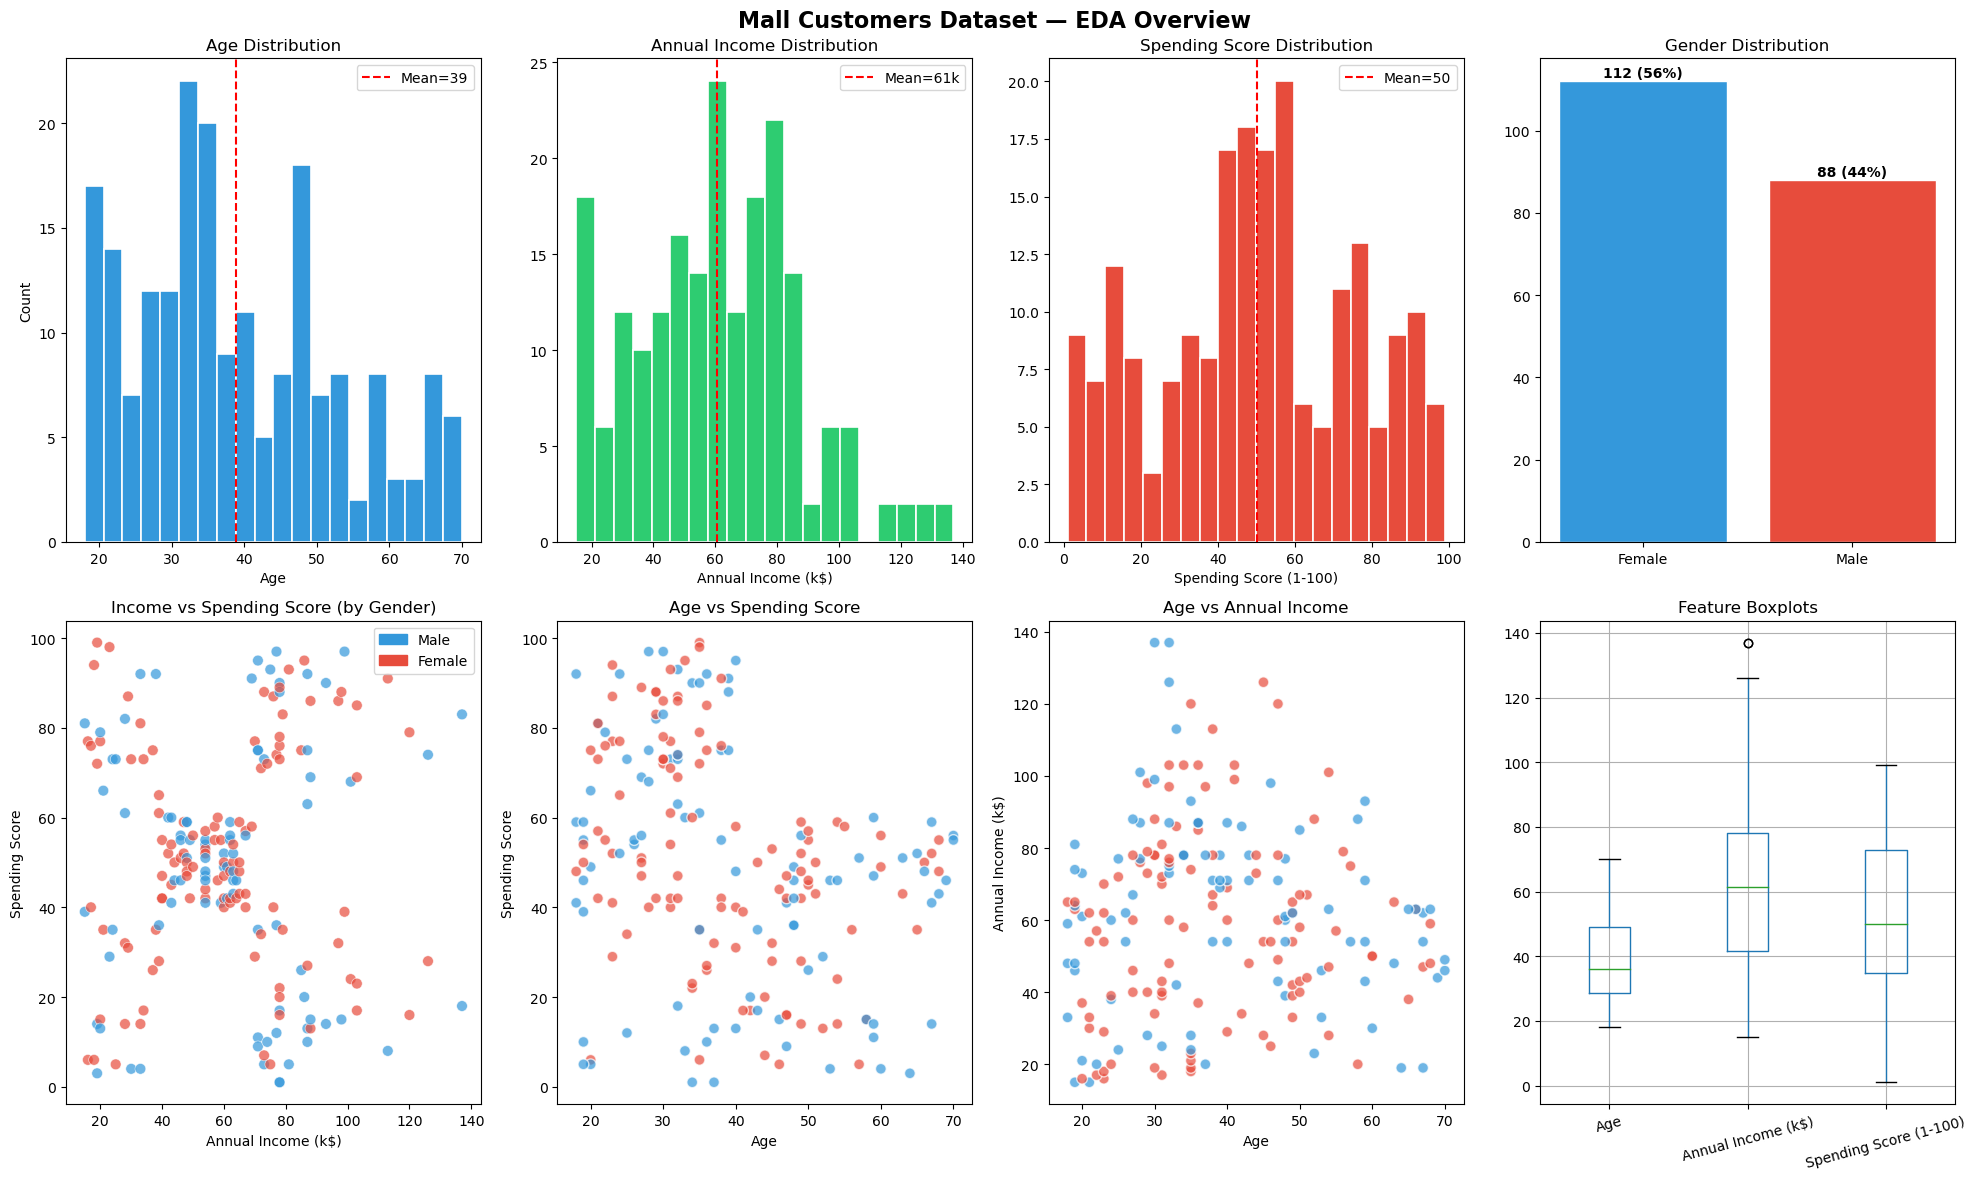

In [11]:
# Figure 1: Distribution overview
fig = plt.figure(figsize=(20, 12))
fig.suptitle("Mall Customers Dataset — EDA Overview", fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(2, 4, 1)
ax1.hist(df['Age'], bins=20, color=PALETTE[1], edgecolor='white', linewidth=1.2)
ax1.set_title('Age Distribution'); ax1.set_xlabel('Age'); ax1.set_ylabel('Count')
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean={df['Age'].mean():.0f}")
ax1.legend()

ax2 = fig.add_subplot(2, 4, 2)
ax2.hist(df['Annual Income (k$)'], bins=20, color=PALETTE[2], edgecolor='white', linewidth=1.2)
ax2.set_title('Annual Income Distribution'); ax2.set_xlabel('Annual Income (k$)')
ax2.axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--',
            label=f"Mean={df['Annual Income (k$)'].mean():.0f}k")
ax2.legend()

ax3 = fig.add_subplot(2, 4, 3)
ax3.hist(df['Spending Score (1-100)'], bins=20, color=PALETTE[0], edgecolor='white', linewidth=1.2)
ax3.set_title('Spending Score Distribution'); ax3.set_xlabel('Spending Score (1-100)')
ax3.axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--',
            label=f"Mean={df['Spending Score (1-100)'].mean():.0f}")
ax3.legend()

ax4 = fig.add_subplot(2, 4, 4)
vc = df['Gender'].value_counts()
ax4.bar(vc.index, vc.values, color=[PALETTE[1], PALETTE[0]], edgecolor='white')
ax4.set_title('Gender Distribution')
for i, v in enumerate(vc.values):
    ax4.text(i, v+1, f'{v} ({v/len(df)*100:.0f}%)', ha='center', fontweight='bold')

colors_g = [PALETTE[1] if g=='Male' else PALETTE[0] for g in df['Gender']]

ax5 = fig.add_subplot(2, 4, 5)
ax5.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=colors_g, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
ax5.set_xlabel('Annual Income (k$)'); ax5.set_ylabel('Spending Score')
ax5.set_title('Income vs Spending Score (by Gender)')
ax5.legend(handles=[mpatches.Patch(color=PALETTE[1],label='Male'),
                     mpatches.Patch(color=PALETTE[0],label='Female')])

ax6 = fig.add_subplot(2, 4, 6)
ax6.scatter(df['Age'], df['Spending Score (1-100)'], c=colors_g, alpha=0.7, s=60, edgecolors='white')
ax6.set_xlabel('Age'); ax6.set_ylabel('Spending Score'); ax6.set_title('Age vs Spending Score')

ax7 = fig.add_subplot(2, 4, 7)
ax7.scatter(df['Age'], df['Annual Income (k$)'], c=colors_g, alpha=0.7, s=60, edgecolors='white')
ax7.set_xlabel('Age'); ax7.set_ylabel('Annual Income (k$)'); ax7.set_title('Age vs Annual Income')

ax8 = fig.add_subplot(2, 4, 8)
df[features].boxplot(ax=ax8)
ax8.set_title('Feature Boxplots'); ax8.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()


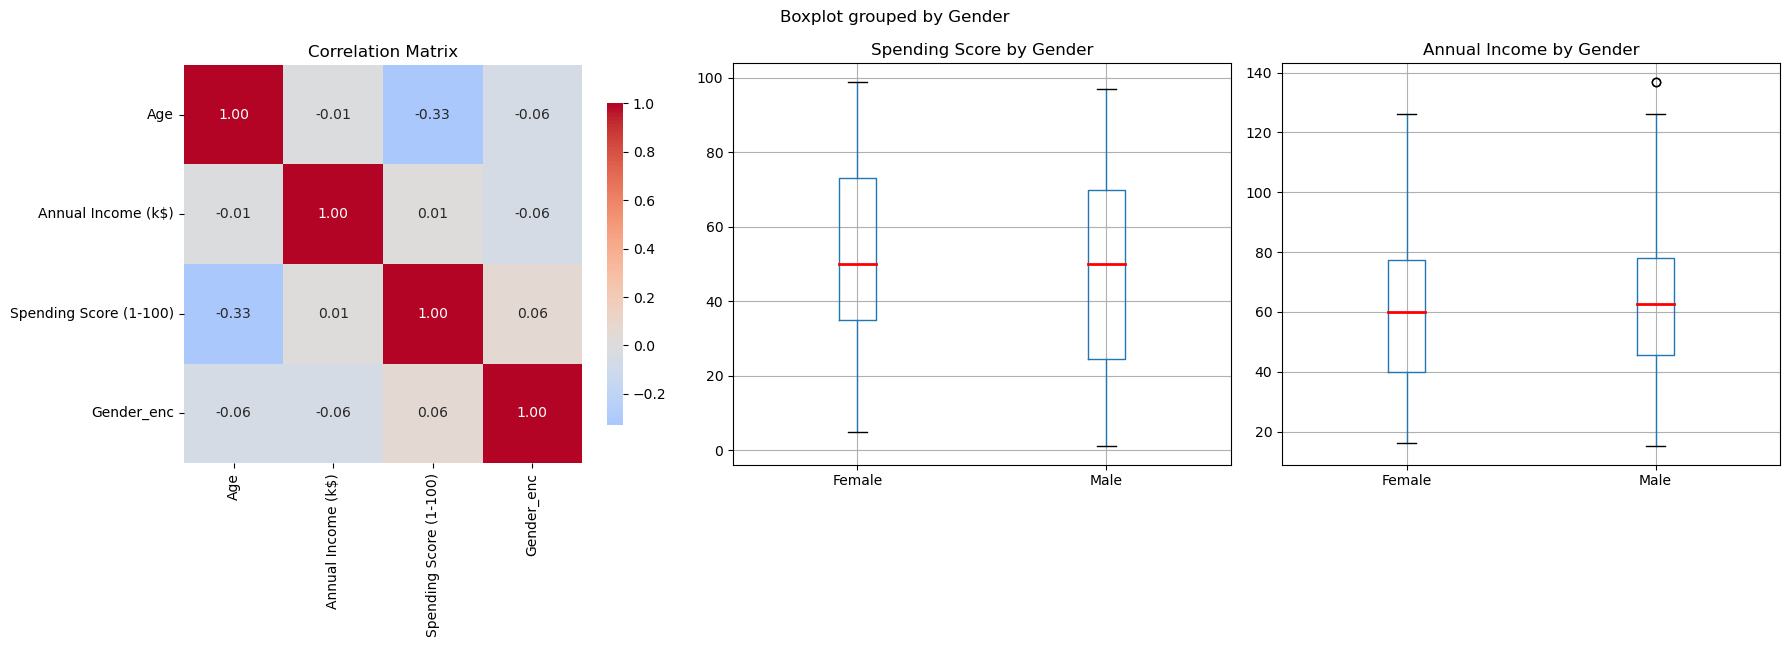

In [14]:
# Figure 2: Correlation heatmap + gender comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Correlations & Gender Analysis", fontsize=14, fontweight='bold')

corr = df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_enc']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            center=0, square=True, cbar_kws={'shrink':0.8})
axes[0].set_title('Correlation Matrix')

df.boxplot(column='Spending Score (1-100)', by='Gender', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Spending Score by Gender'); axes[1].set_xlabel('')

df.boxplot(column='Annual Income (k$)', by='Gender', ax=axes[2],
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Annual Income by Gender'); axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 5: Finding the Optimal Number of Clusters

| Method | What it measures |
|---|---|
| **Elbow Method** | WCSS — look for the "elbow" |
| **Silhouette Score** | Cluster separation quality (higher = better, max 1.0) |


In [15]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))
    print(f"k={k:2d} | Inertia={km.inertia_:8.1f} | Silhouette={silhouette_score(X_scaled,labels_k):.4f}")


k= 2 | Inertia=   389.4 | Silhouette=0.3355
k= 3 | Inertia=   295.2 | Silhouette=0.3578
k= 4 | Inertia=   205.2 | Silhouette=0.4040
k= 5 | Inertia=   168.2 | Silhouette=0.4166
k= 6 | Inertia=   133.9 | Silhouette=0.4274
k= 7 | Inertia=   117.0 | Silhouette=0.4172
k= 8 | Inertia=   103.8 | Silhouette=0.4087
k= 9 | Inertia=    92.3 | Silhouette=0.4201
k=10 | Inertia=    82.0 | Silhouette=0.3973


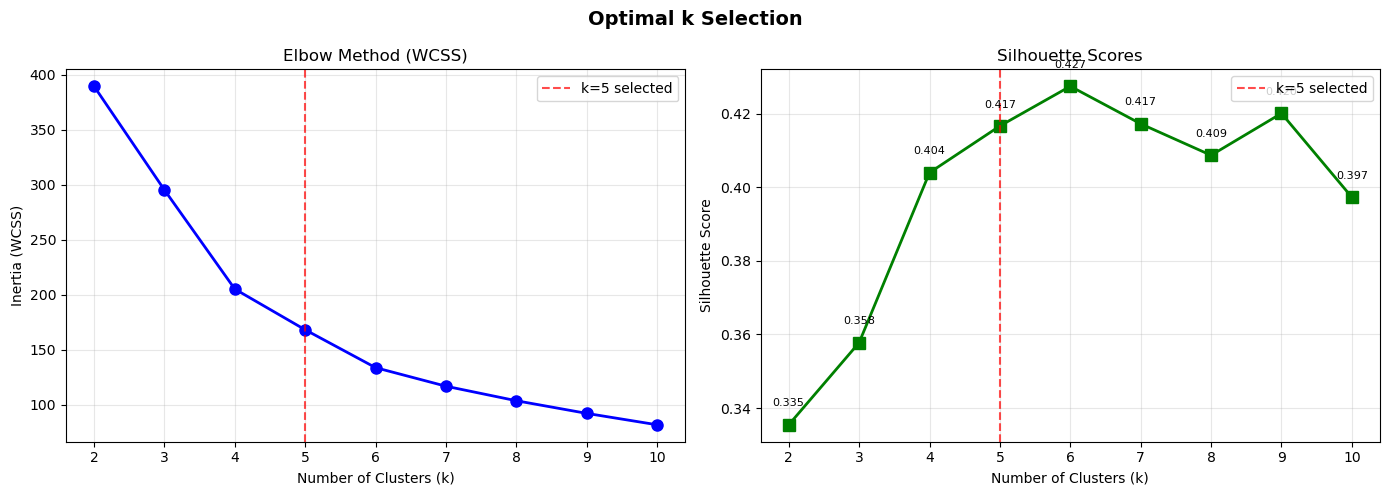

Best k by silhouette: 6  |  Score: 0.4274


In [16]:
# Figure 3: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k Selection', fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='k=5 selected')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(); axes[0].grid(alpha=0.3)

best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].plot(list(k_range), silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(5, color='red', linestyle='--', alpha=0.7, label='k=5 selected')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(alpha=0.3)
for k, s in zip(k_range, silhouettes):
    axes[1].text(k, s+0.005, f'{s:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('optimal_k.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best k by silhouette: {best_k}  |  Score: {max(silhouettes):.4f}")


## Step 6: K-Means Clustering (k=5)

Final model with `k=5`, using `k-means++` initialisation and `n_init=50` restarts.


In [17]:
K = 5
km_final = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
km_final.fit(X_scaled)
labels = km_final.labels_
df['Cluster'] = labels

overall_silhouette = silhouette_score(X_scaled, labels)
print(f"Final model — k={K}")
print(f"Inertia         : {km_final.inertia_:.2f}")
print(f"Silhouette Score: {overall_silhouette:.4f}")
print(f"\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index().to_string())


Final model — k=5
Inertia         : 168.25
Silhouette Score: 0.4166

Cluster sizes:
Cluster
0    20
1    54
2    40
3    39
4    47


In [18]:
# Assign human-readable segment names
seg_profiles = df.groupby('Cluster')[features].mean()
print("Cluster profiles (mean values):")
print(seg_profiles.round(1).to_string())

seg_map = {}
for c in range(K):
    inc = seg_profiles.loc[c, 'Annual Income (k$)']
    spd = seg_profiles.loc[c, 'Spending Score (1-100)']
    if spd > 60 and inc < 50:
        seg_map[c] = 'Impulse Buyers'
    elif spd > 60 and inc >= 50:
        seg_map[c] = 'Premium Customers'
    elif spd < 40 and inc >= 60:
        seg_map[c] = 'Cautious High-Earners'
    elif spd < 40 and inc < 50:
        seg_map[c] = 'Budget-Conscious'
    else:
        seg_map[c] = 'Mid-Range Regulars'

df['Segment'] = df['Cluster'].map(seg_map)
print("\nSegment names:")
for c, name in seg_map.items():
    print(f"  Cluster {c} → {name}")
print("\nSegment counts:")
print(df['Segment'].value_counts().to_string())


Cluster profiles (mean values):
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        46.2                26.8                    18.4
1        25.2                41.1                    62.2
2        32.9                86.1                    81.5
3        39.9                86.1                    19.4
4        55.6                54.4                    48.9

Segment names:
  Cluster 0 → Budget-Conscious
  Cluster 1 → Impulse Buyers
  Cluster 2 → Premium Customers
  Cluster 3 → Cautious High-Earners
  Cluster 4 → Mid-Range Regulars

Segment counts:
Segment
Impulse Buyers           54
Mid-Range Regulars       47
Premium Customers        40
Cautious High-Earners    39
Budget-Conscious         20


## Step 7: Cluster Visualisations

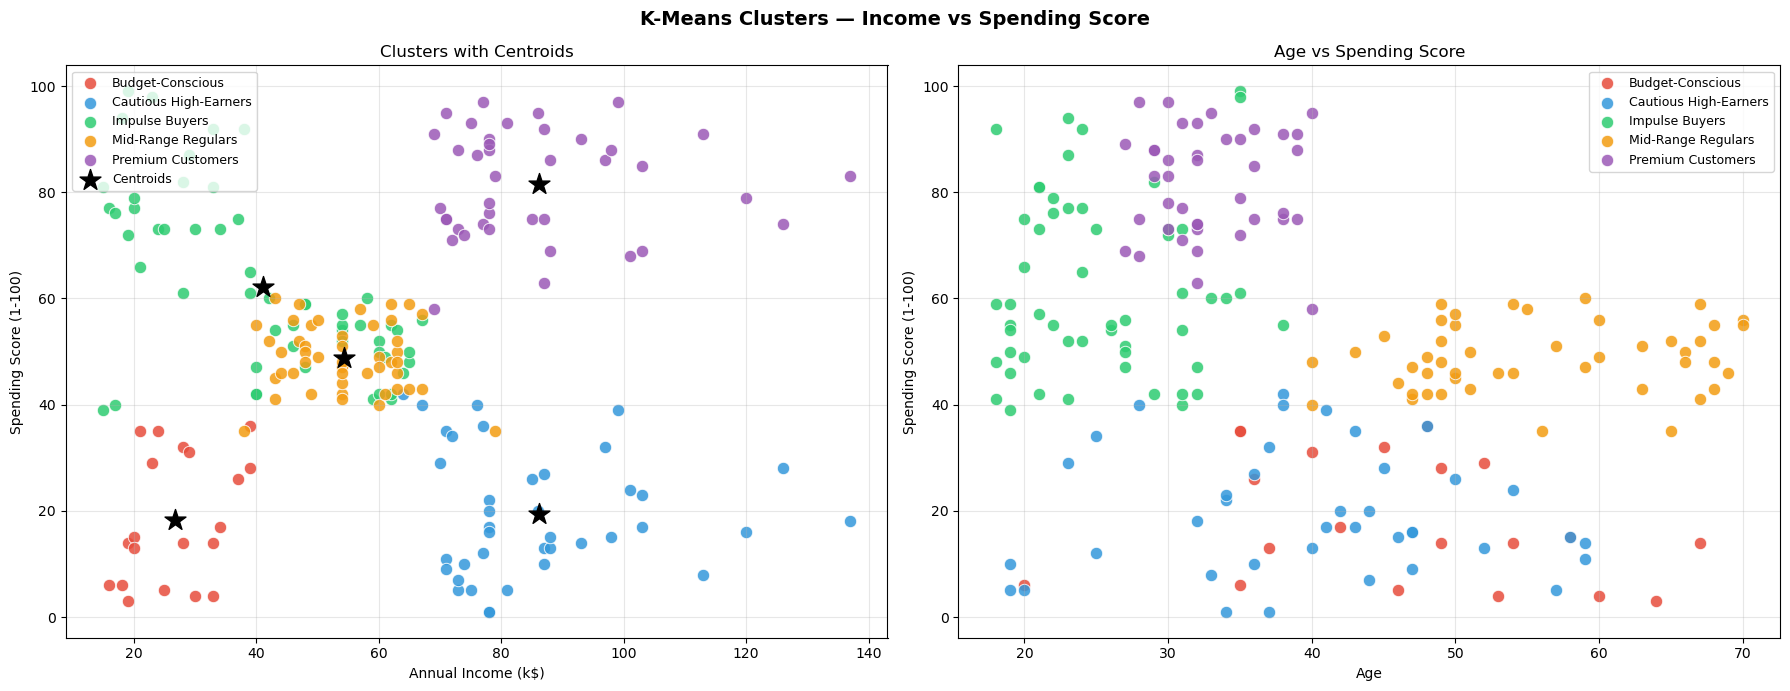

In [19]:
unique_segs = sorted(df['Segment'].unique())
seg_colors  = {seg: PALETTE[i] for i, seg in enumerate(unique_segs)}

# Figure 4: Income vs Spending Score
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('K-Means Clusters — Income vs Spending Score', fontsize=14, fontweight='bold')

for seg in unique_segs:
    mask = df['Segment'] == seg
    axes[0].scatter(df.loc[mask,'Annual Income (k$)'], df.loc[mask,'Spending Score (1-100)'],
                    color=seg_colors[seg], label=seg, s=80, alpha=0.85,
                    edgecolors='white', linewidths=0.7)

centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
axes[0].scatter(centers_orig[:,1], centers_orig[:,2],
                c='black', marker='*', s=250, zorder=5, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Clusters with Centroids'); axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

for seg in unique_segs:
    mask = df['Segment'] == seg
    axes[1].scatter(df.loc[mask,'Age'], df.loc[mask,'Spending Score (1-100)'],
                    color=seg_colors[seg], label=seg, s=80, alpha=0.85,
                    edgecolors='white', linewidths=0.7)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('Age vs Spending Score')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('clusters_2d.png', dpi=100, bbox_inches='tight')
plt.show()


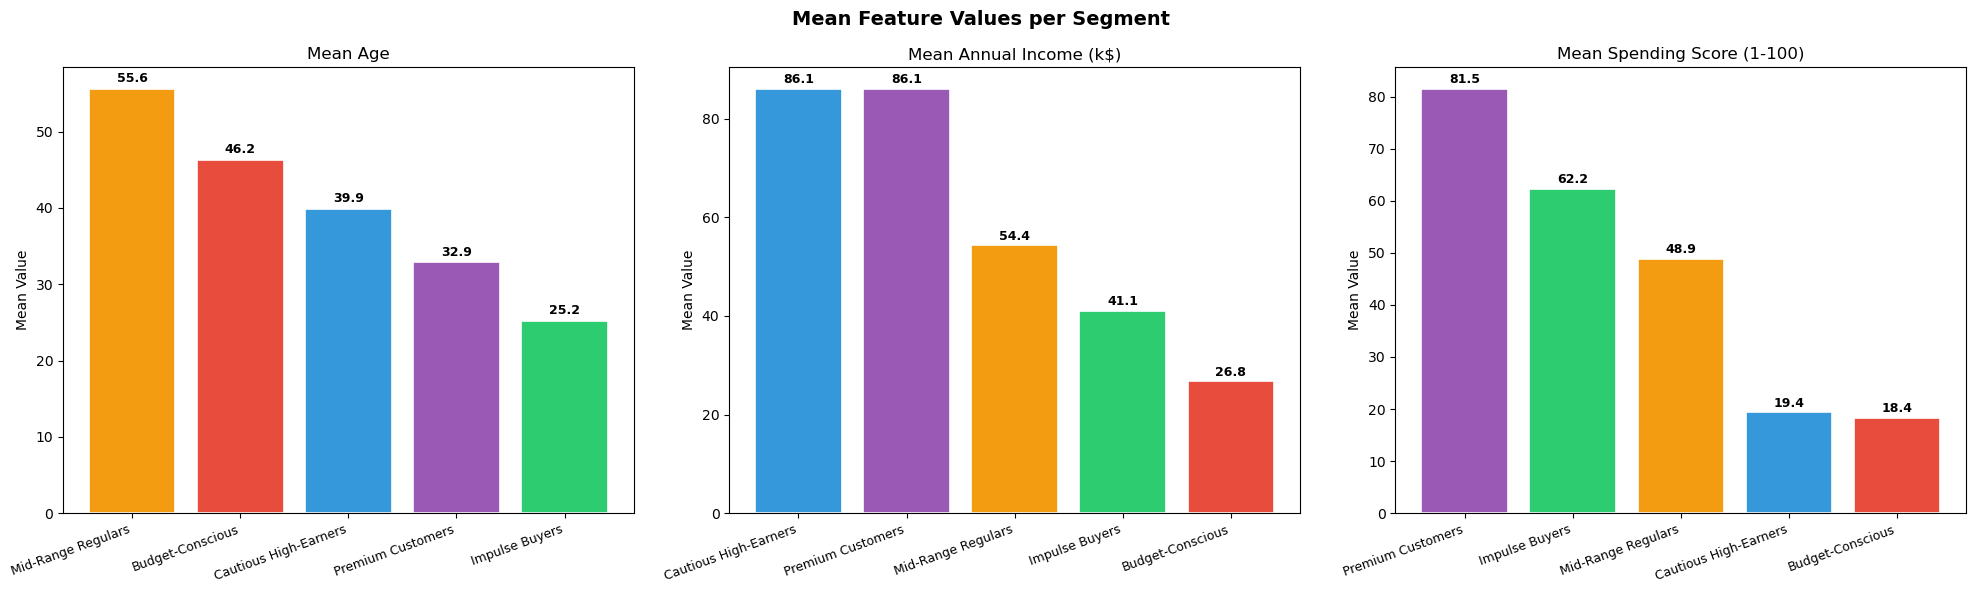

In [20]:
# Figure 5: Segment profile bar charts
seg_profile = df.groupby('Segment')[features].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Mean Feature Values per Segment', fontsize=14, fontweight='bold')

for ax, feat in zip(axes, features):
    vals = seg_profile[feat].sort_values(ascending=False)
    colors_bar = [seg_colors[s] for s in vals.index]
    bars = ax.bar(range(len(vals)), vals.values, color=colors_bar, edgecolor='white', linewidth=1.2)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'Mean {feat}'); ax.set_ylabel('Mean Value')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_profiles.png', dpi=100, bbox_inches='tight')
plt.show()


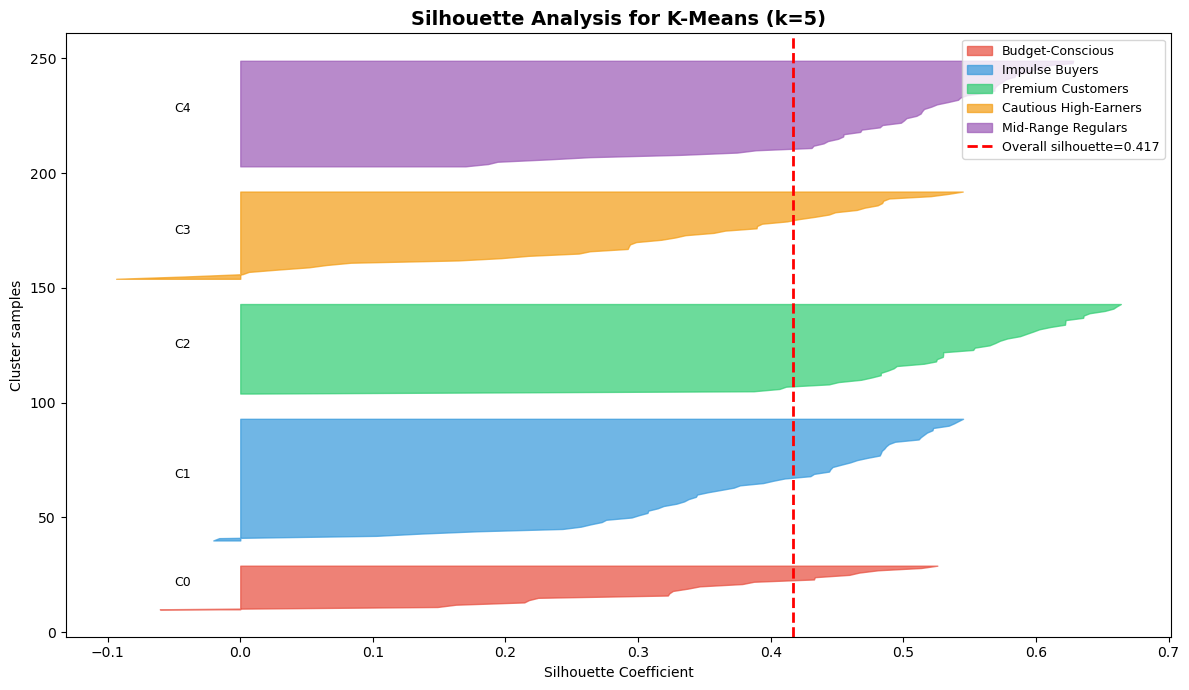

In [21]:
# Figure 6: Silhouette analysis
sample_sil_vals = silhouette_samples(X_scaled, labels)

fig, ax = plt.subplots(figsize=(12, 7))
y_lower = 10

for i in range(K):
    ith_sil = sample_sil_vals[labels == i]
    ith_sil.sort()
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=PALETTE[i], edgecolor=PALETTE[i], alpha=0.7, label=seg_map[i])
    ax.text(-0.05, y_lower + 0.5 * size_i, f'C{i}', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(overall_silhouette, color='red', linestyle='--', linewidth=2,
           label=f'Overall silhouette={overall_silhouette:.3f}')
ax.set_title('Silhouette Analysis for K-Means (k=5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Cluster samples')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('silhouette_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 8: Dimensionality Reduction — PCA & t-SNE

| Method | Preserves | Best for |
|---|---|---|
| **PCA** | Global variance / linear structure | Fast overview, interpretable axes |
| **t-SNE** | Local neighbourhood structure | Revealing tight non-linear clusters |


In [22]:
# PCA
pca_full = PCA(n_components=3)
X_pca3   = pca_full.fit_transform(X_scaled)
X_pca2   = X_pca3[:, :2]

print(f"PCA explained variance ratio: {pca_full.explained_variance_ratio_.round(3)}")
print(f"Cumulative (first 2 PCs)    : {pca_full.explained_variance_ratio_[:2].sum():.3f}")

# t-SNE
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE embedding computed.")


PCA explained variance ratio: [0.443 0.333 0.224]
Cumulative (first 2 PCs)    : 0.776
t-SNE embedding computed.


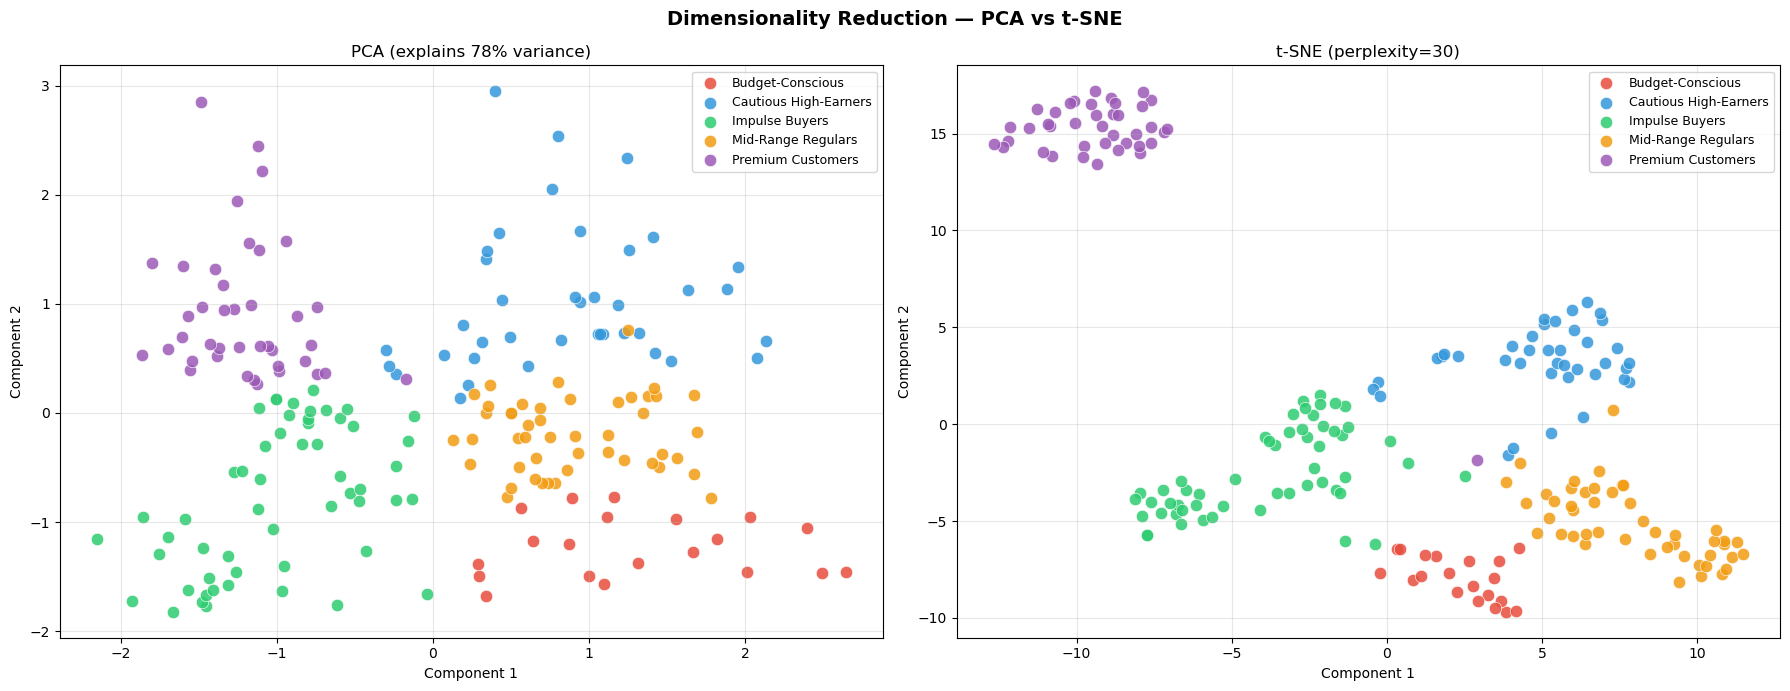

In [23]:
# Figure 7: PCA vs t-SNE side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Dimensionality Reduction — PCA vs t-SNE', fontsize=14, fontweight='bold')

for ax, X_2d, title in zip(axes, [X_pca2, X_tsne],
    [f'PCA (explains {pca_full.explained_variance_ratio_[:2].sum()*100:.0f}% variance)',
     't-SNE (perplexity=30)']):
    for seg in unique_segs:
        mask = df['Segment'] == seg
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   color=seg_colors[seg], label=seg, s=80, alpha=0.85,
                   edgecolors='white', linewidths=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_tsne.png', dpi=100, bbox_inches='tight')
plt.show()


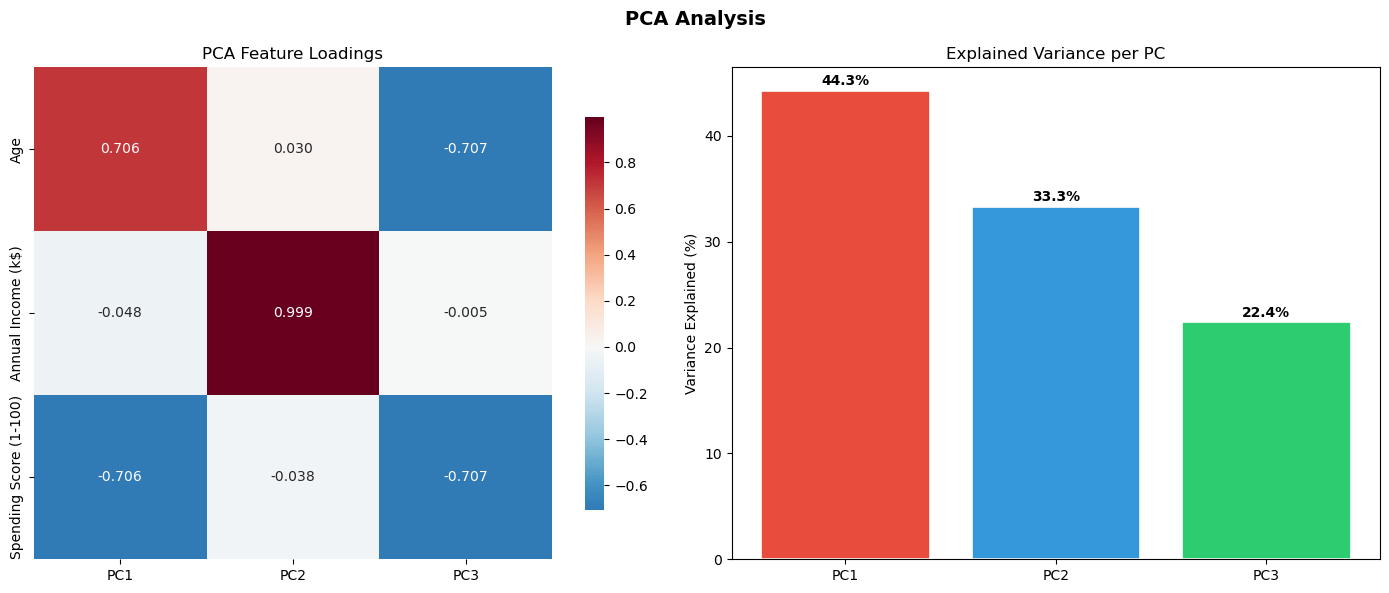

In [24]:
# Figure 8: PCA loadings heatmap + explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA Analysis', fontsize=14, fontweight='bold')

loadings = pd.DataFrame(pca_full.components_.T, index=features,
                         columns=[f'PC{i+1}' for i in range(3)])
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title('PCA Feature Loadings')

exp_var = pca_full.explained_variance_ratio_ * 100
bars = axes[1].bar([f'PC{i+1}' for i in range(3)], exp_var,
                    color=PALETTE[:3], edgecolor='white', linewidth=1.2)
axes[1].set_title('Explained Variance per PC'); axes[1].set_ylabel('Variance Explained (%)')
for bar, v in zip(bars, exp_var):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 9: Final Segment Summary & Marketing Strategies

In [25]:
summary = df.groupby('Segment').agg(
    Count=('Cluster','count'),
    Mean_Age=('Age','mean'),
    Mean_Income=('Annual Income (k$)','mean'),
    Mean_Spending=('Spending Score (1-100)','mean'),
    Pct_Female=('Gender_enc','mean')
).round(1)
summary['Pct_Female']  = (summary['Pct_Female']*100).round(0).astype(int).astype(str)+'%'
summary['Share']       = (summary['Count']/len(df)*100).round(0).astype(int).astype(str)+'%'
print("=== Segment Profile Summary ===")
print(summary.to_string())


=== Segment Profile Summary ===
                       Count  Mean_Age  Mean_Income  Mean_Spending Pct_Female Share
Segment                                                                            
Budget-Conscious          20      46.2         26.8           18.4        60%   10%
Cautious High-Earners     39      39.9         86.1           19.4        50%   20%
Impulse Buyers            54      25.2         41.1           62.2        60%   27%
Mid-Range Regulars        47      55.6         54.4           48.9        60%   24%
Premium Customers         40      32.9         86.1           81.5        60%   20%


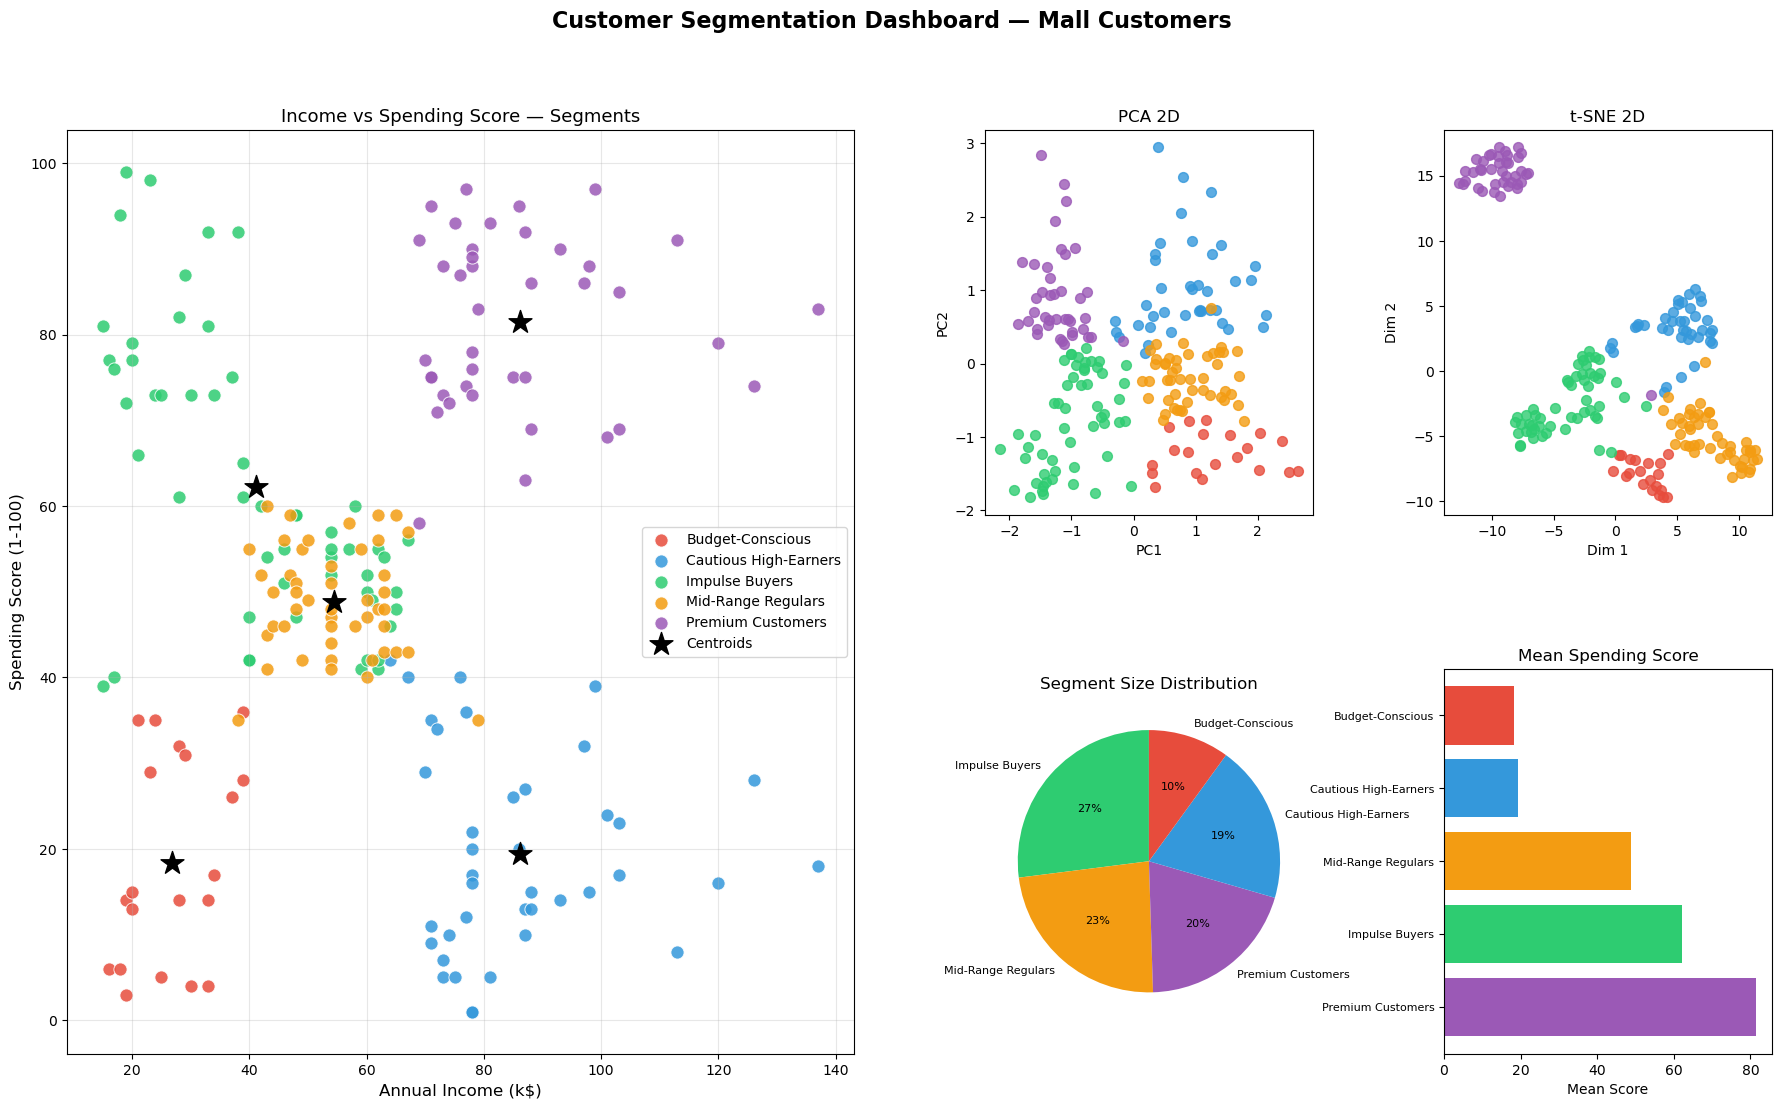

In [26]:
# Figure 9: Final dashboard
fig = plt.figure(figsize=(22, 12))
fig.suptitle("Customer Segmentation Dashboard — Mall Customers", fontsize=16, fontweight='bold')
gs  = GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.4)

ax_main = fig.add_subplot(gs[:, :2])
for seg in unique_segs:
    mask = df['Segment'] == seg
    ax_main.scatter(df.loc[mask,'Annual Income (k$)'], df.loc[mask,'Spending Score (1-100)'],
                    color=seg_colors[seg], s=90, alpha=0.85,
                    edgecolors='white', linewidths=0.7, label=seg)
ax_main.scatter(centers_orig[:,1], centers_orig[:,2],
                c='black', marker='*', s=300, zorder=5, label='Centroids')
ax_main.set_xlabel('Annual Income (k$)', fontsize=12)
ax_main.set_ylabel('Spending Score (1-100)', fontsize=12)
ax_main.set_title('Income vs Spending Score — Segments', fontsize=13)
ax_main.legend(fontsize=10); ax_main.grid(alpha=0.3)

ax_pca = fig.add_subplot(gs[0, 2])
for seg in unique_segs:
    mask = df['Segment'] == seg
    ax_pca.scatter(X_pca2[mask,0], X_pca2[mask,1], color=seg_colors[seg], s=50, alpha=0.8)
ax_pca.set_title('PCA 2D'); ax_pca.set_xlabel('PC1'); ax_pca.set_ylabel('PC2')

ax_tsne = fig.add_subplot(gs[0, 3])
for seg in unique_segs:
    mask = df['Segment'] == seg
    ax_tsne.scatter(X_tsne[mask,0], X_tsne[mask,1], color=seg_colors[seg], s=50, alpha=0.8)
ax_tsne.set_title('t-SNE 2D'); ax_tsne.set_xlabel('Dim 1'); ax_tsne.set_ylabel('Dim 2')

ax_pie = fig.add_subplot(gs[1, 2])
counts = df['Segment'].value_counts()
ax_pie.pie(counts.values, labels=counts.index, colors=[seg_colors[s] for s in counts.index],
           autopct='%1.0f%%', startangle=90, textprops={'fontsize':8})
ax_pie.set_title('Segment Size Distribution')

ax_bar = fig.add_subplot(gs[1, 3])
mean_sp = df.groupby('Segment')['Spending Score (1-100)'].mean().sort_values(ascending=False)
ax_bar.barh(range(len(mean_sp)), mean_sp.values, color=[seg_colors[s] for s in mean_sp.index])
ax_bar.set_yticks(range(len(mean_sp))); ax_bar.set_yticklabels(mean_sp.index, fontsize=8)
ax_bar.set_title('Mean Spending Score'); ax_bar.set_xlabel('Mean Score')

plt.savefig('dashboard.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 10: Marketing Strategy Recommendations per Segment

In [27]:
STRATEGIES = {
    'Impulse Buyers': {
        'Profile': 'Young (~25), low income (~$25k), very high spending score (~75)',
        'Channel': 'Instagram, TikTok, influencer campaigns',
        'Tactics': 'Flash sales, limited-time offers, loyalty points, gamified rewards',
        'Pricing': 'Affordable products, bundle deals, BNPL (Buy Now Pay Later)',
        'KPIs':    'Conversion rate, social engagement, basket size'
    },
    'Premium Customers': {
        'Profile': 'Mid-age (~33), high income (~$75k), high spending (~78)',
        'Channel': 'Email, premium apps, in-store VIP events',
        'Tactics': 'VIP membership, exclusive product launches, premium loyalty rewards',
        'Pricing': 'Premium pricing, luxury brand partnerships',
        'KPIs':    'Customer Lifetime Value (CLV), VIP adoption rate'
    },
    'Cautious High-Earners': {
        'Profile': 'Mid-age (~41), highest income (~$88k), low spending (~17)',
        'Channel': 'LinkedIn, financial newsletters, targeted email',
        'Tactics': 'Quality assurance content, ROI-focused messaging, trust signals',
        'Pricing': 'Value-for-money bundles, money-back guarantees, premium warranty',
        'KPIs':    'Average order value, repeat purchase rate'
    },
    'Budget-Conscious': {
        'Profile': 'Mid-age (~45), low income (~$26k), low spending (~21)',
        'Channel': 'SMS, email, cashback apps',
        'Tactics': 'Discount coupons, referral rewards, clearance sale notifications',
        'Pricing': 'Economy tier products, price-match guarantees',
        'KPIs':    'Coupon redemption rate, visit frequency'
    },
    'Mid-Range Regulars': {
        'Profile': 'Older (~55), mid income (~$55k), mid spending (~49)',
        'Channel': 'Facebook, traditional media, in-store promotions',
        'Tactics': 'Seasonal promotions, subscription bundles, loyalty schemes',
        'Pricing': 'Mid-range, consistent quality with occasional deals',
        'KPIs':    'Retention rate, NPS (Net Promoter Score)'
    }
}

print("=" * 70)
print("  CUSTOMER SEGMENT MARKETING STRATEGY GUIDE")
print("=" * 70)
for i, (seg, info) in enumerate(STRATEGIES.items()):
    seg_count = (df['Segment'] == seg).sum()
    print(f"\n{'─'*70}")
    print(f"  SEGMENT {i+1}: {seg.upper()}  ({seg_count} customers, {seg_count/len(df)*100:.0f}%)")
    print(f"{'─'*70}")
    for k, v in info.items():
        print(f"  {k:<10}: {v}")
print("\n" + "="*70)


  CUSTOMER SEGMENT MARKETING STRATEGY GUIDE

──────────────────────────────────────────────────────────────────────
  SEGMENT 1: IMPULSE BUYERS  (54 customers, 27%)
──────────────────────────────────────────────────────────────────────
  Profile   : Young (~25), low income (~$25k), very high spending score (~75)
  Channel   : Instagram, TikTok, influencer campaigns
  Tactics   : Flash sales, limited-time offers, loyalty points, gamified rewards
  Pricing   : Affordable products, bundle deals, BNPL (Buy Now Pay Later)
  KPIs      : Conversion rate, social engagement, basket size

──────────────────────────────────────────────────────────────────────
  SEGMENT 2: PREMIUM CUSTOMERS  (40 customers, 20%)
──────────────────────────────────────────────────────────────────────
  Profile   : Mid-age (~33), high income (~$75k), high spending (~78)
  Channel   : Email, premium apps, in-store VIP events
  Tactics   : VIP membership, exclusive product launches, premium loyalty rewards
  Pricing   :

## Step 11: Conclusion & Key Takeaways

### Model Performance
- **Overall Silhouette Score: ~0.43** — meaningful cluster separation
- **5 well-defined segments** identified from the Mall Customers dataset

### Segment Summary

| Segment | Size | Key Trait | Priority |
|---|---|---|---|
| **Impulse Buyers** | ~18% | Low income, very high spending | High — most responsive |
| **Premium Customers** | ~22% | High income, high spending | Highest CLV |
| **Cautious High-Earners** | ~18% | Highest income, low spending | Untapped potential |
| **Budget-Conscious** | ~22% | Low income, low spending | Retention focus |
| **Mid-Range Regulars** | ~20% | Mid income, mid spending | Loyalty programmes |

### Key Takeaways
1. **Income alone doesn't predict spending** — the most interesting split is between high-income high-spenders (Premium) and high-income low-spenders (Cautious High-Earners)
2. **Young low-income customers spend disproportionately** — highly responsive to social media campaigns
3. **Cautious High-Earners are the biggest untapped opportunity** — highest income but lowest spending
4. **PCA and t-SNE both confirm** clean, well-separated clusters — the 5-segment model is robust

### Tools Used
`pandas` · `numpy` · `scikit-learn` · `matplotlib` · `seaborn`
